Normal

BEML | Mean: 0.0003  Std: 0.0264
GLAXO | Mean: 0.0004  Std: 0.0134


/tmp/ipykernel_4070/580231453.py:21: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sn.distplot(glaxo.gain, label='GLAXO')
/tmp/ipykernel_4070/580231453.py:22: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sn.distplot(beml.gain,  label='BEML')


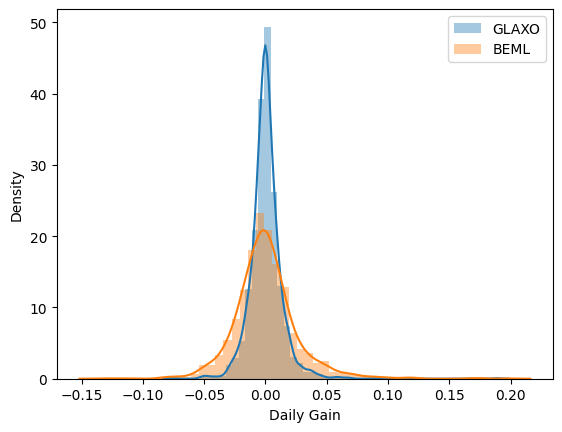

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

# ── Load & Prepare Data ──────────────────────────────
beml  = pd.read_csv('BEML.csv')[  ['Date', 'Close']]
glaxo = pd.read_csv('GLAXO.csv')[['Date', 'Close']]

for df in [beml, glaxo]:
    df.set_index(pd.DatetimeIndex(df['Date']), inplace=True)
    df['gain'] = df.Close.pct_change()   # daily % return

beml.dropna(inplace=True)
glaxo.dropna(inplace=True)

# ── Statistics ───────────────────────────────────────
for name, df in [(  'BEML', beml), ('GLAXO', glaxo)]:
    print(f"{name} | Mean: {df.gain.mean():.4f}  Std: {df.gain.std():.4f}")

# ── Plot ─────────────────────────────────────────────
sn.distplot(glaxo.gain, label='GLAXO')
sn.distplot(beml.gain,  label='BEML')
plt.xlabel('Daily Gain'); plt.ylabel('Density'); plt.legend(); plt.show()

Binomial

P(exactly 5 return) : 0.0319
P(at most 5 return) : 0.9887
P(more than 5 return): 0.0113
Mean=2.0  Variance=1.8


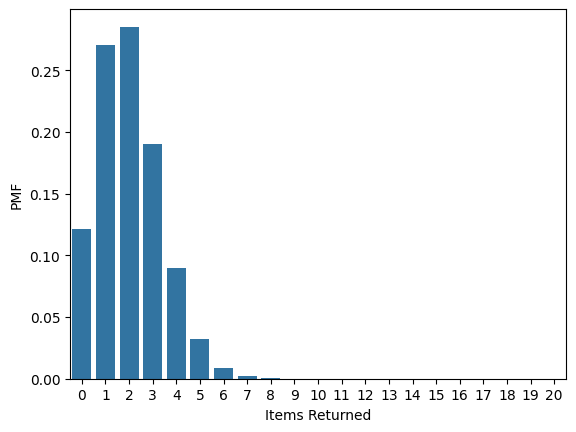

In [2]:
from scipy import stats
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

# ── Parameters ───────────────────────────────────────
n, p = 20, 0.1   # 20 customers, 10% return rate

# ── Key Probabilities ─────────────────────────────────
print(f"P(exactly 5 return) : {stats.binom.pmf(5, n, p):.4f}")
print(f"P(at most 5 return) : {stats.binom.cdf(5, n, p):.4f}")
print(f"P(more than 5 return): {1 - stats.binom.cdf(5, n, p):.4f}")
mean, var = stats.binom.stats(n, p)
print(f"Mean={mean}  Variance={var}")

# ── Plot PMF ─────────────────────────────────────────
pmf_df = pd.DataFrame({
    'returns': range(0, 21),
    'pmf'    : stats.binom.pmf(range(0, 21), n, p)
})
sn.barplot(x='returns', y='pmf', data=pmf_df)
plt.xlabel('Items Returned'); plt.ylabel('PMF'); plt.show()

Exponential

P(fail before 1000 hrs) : 0.6321
P(survive past 2000 hrs): 0.1353
P10 life (10% fail by)  : 105.36 hrs


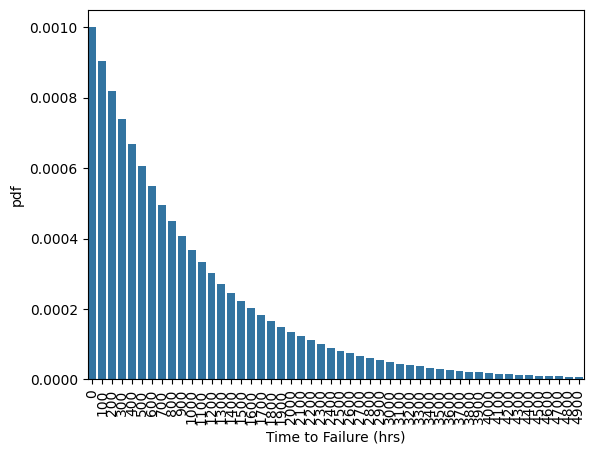

In [3]:
from scipy import stats
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

# ── Parameter ────────────────────────────────────────
scale = 1000   # MTBF = 1000 hours  →  λ = 1/1000

# ── Key Probabilities ─────────────────────────────────
print(f"P(fail before 1000 hrs) : {stats.expon.cdf(1000, scale=scale):.4f}")
print(f"P(survive past 2000 hrs): {1 - stats.expon.cdf(2000, scale=scale):.4f}")
print(f"P10 life (10% fail by)  : {stats.expon.ppf(0.1, scale=scale):.2f} hrs")

# ── Plot PDF ─────────────────────────────────────────
hrs = range(0, 5000, 100)
pdf_df = pd.DataFrame({'hours': hrs, 'pdf': stats.expon.pdf(hrs, scale=scale)})

sn.barplot(x='hours', y='pdf', data=pdf_df)
plt.xticks(rotation=90); plt.xlabel('Time to Failure (hrs)'); plt.show()

Poisson

P(≤5 calls in 1 hr)       : 0.0671
P(>30 calls in 3 hrs)     : 0.4516
P(exactly 10 calls)       : 0.1251


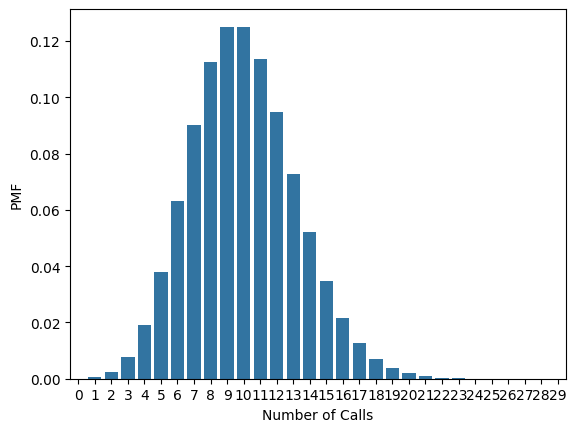

In [4]:
from scipy import stats
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

# ── Parameter ────────────────────────────────────────
mu = 10   # avg 10 calls per hour

# ── Key Probabilities ─────────────────────────────────
print(f"P(≤5 calls in 1 hr)       : {stats.poisson.cdf(5, mu):.4f}")
print(f"P(>30 calls in 3 hrs)     : {1 - stats.poisson.cdf(30, 30):.4f}")
print(f"P(exactly 10 calls)       : {stats.poisson.pmf(10, mu):.4f}")

# ── Plot PMF ─────────────────────────────────────────
pmf_df = pd.DataFrame({
    'calls': range(0, 30),
    'pmf'  : stats.poisson.pmf(range(0, 30), mu)
})
sn.barplot(x='calls', y='pmf', data=pmf_df)
plt.xlabel('Number of Calls'); plt.ylabel('PMF'); plt.show()